<a href="https://colab.research.google.com/github/dpratap17/IntelligentFinanceResearch/blob/main/graph_construction_paysim_momtsim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Construction: PaySim & MoMTSim → GNN-Ready Format
**Research:** Explainable and Adaptive Hybrid Deep Learning for Financial Fraud Detection  
**Author:** Dharmendra Pratap Singh (25/RCO/10), DTU

Converts raw PaySim and MoMTSim CSV files into PyTorch Geometric `Data` objects and saves everything directly to **Google Drive**.

| Component | Description |
|-----------|-------------|
| **Nodes** | Unique accounts (senders + receivers) |
| **Edges** | Directed transactions (sender → receiver) |
| **Node features** | Aggregated per-account statistics |
| **Edge features** | Amount, time step, transaction type |
| **Node labels** | 1 if account involved in any fraud, else 0 |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## STEP 0 — Mount Google Drive & Configure Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted.


In [ ]:
import os

# ══════════════════════════════════════════════════════════════════
#  EDIT ONLY THIS CELL — all paths are derived from DRIVE_BASE
# ══════════════════════════════════════════════════════════════════

# Root folder in Drive — all graph datasets (Elliptic, T-Finance, PaySim etc.) live here
DRIVE_BASE      = '/content/drive/MyDrive/FraudDetection_Research/datasets'

# Input CSV files (uploaded to Colab /content/ or also on Drive)
PAYSIM_CSV      = '/content/drive/MyDrive/Datasets/paysim/PS_20174392719_1491204439457_log.csv'  # <- update filename
MOMTSIM_CSV     = '/content/drive/MyDrive/Datasets/Synthetic Mobile Money Transaction Dataset/synthetic_mobile_money_transaction_dataset.csv' # <- update filename

# Sampling — set to None to use the full dataset
PAYSIM_SUBSAMPLE_SIZE  = 500_000
MOMTSIM_SUBSAMPLE_SIZE = 300_000
N_TEMPORAL_SPLITS      = 3

# ── Auto-derived sub-folders (no need to edit below) ──
PAYSIM_OUT_DIR  = os.path.join(DRIVE_BASE, 'paysim')
MOMTSIM_OUT_DIR = os.path.join(DRIVE_BASE, 'momtsim')
PLOTS_DIR       = os.path.join(DRIVE_BASE, 'plots')

for d in [DRIVE_BASE, PAYSIM_OUT_DIR, MOMTSIM_OUT_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive output directories ready:')
print(f'  PaySim  → {PAYSIM_OUT_DIR}')
print(f'  MoMTSim → {MOMTSIM_OUT_DIR}')
print(f'  Plots   → {PLOTS_DIR}')

Drive output directories ready:
  PaySim  → /content/drive/MyDrive/FraudDetection_Research/datasets/paysim
  MoMTSim → /content/drive/MyDrive/FraudDetection_Research/datasets/momtsim
  Plots   → /content/drive/MyDrive/FraudDetection_Research/datasets/plots


## STEP 1 — Install Dependencies

In [ ]:
import torch
print(f'PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}')

!pip install torch_geometric -q
!pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html -q
!pip install networkx matplotlib scikit-learn pandas numpy -q

print('\n✅ All dependencies installed.')

PyTorch: 2.10.0+cu128 | CUDA: True

✅ All dependencies installed.


In [ ]:
import os, json
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings; warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports OK | device: {device}')

✅ Imports OK | device: cuda


## STEP 2 — Shared Utility Functions

In [ ]:
# ─────────────────────────────────────────────────────────
# 1. AUTO-DETECT COLUMNS
# ─────────────────────────────────────────────────────────
def detect_columns(df, dataset_name):
    cols = {c.lower(): c for c in df.columns}
    candidates = {
        'sender'  : ['nameorig','sender','source','payer','initiator','from_account','from'],
        'receiver': ['namedest','receiver','destination','payee','recipient','to_account','to'],
        'label'   : ['isfraud','fraud','label','is_fraud','fraudlabel','fraud_label'],
        'amount'  : ['amount','amt','value','transactionamount','transaction_amount'],
        'time'    : ['step','timestamp','time','hour','timestep','time_step'],
        'type'    : ['type','transactiontype','txn_type','transaction_type'],
    }
    result = {}
    print(f'\n=== {dataset_name} — column detection ===')
    for field, cands in candidates.items():
        found = next((cols[c] for c in cands if c in cols), None)
        result[field] = found
        print(f'  {field:10s}: {found if found else "❌ NOT FOUND"}')
    missing = [k for k in ['sender','receiver','label','amount','time'] if not result[k]]
    if missing:
        print(f'\n⚠️  MISSING: {missing} — manually set them in the override cell.')
    else:
        print('\n✅ All critical columns detected.')
    return result


# ─────────────────────────────────────────────────────────
# 2. STRATIFIED SUBSAMPLE
# ─────────────────────────────────────────────────────────
def stratified_subsample(df, label_col, max_size):
    if max_size is None or len(df) <= max_size:
        print(f'Using full dataset: {len(df):,} rows')
        return df.copy()
    fraud  = df[df[label_col] == 1]
    legit  = df[df[label_col] == 0]
    n_legit = min(max_size - len(fraud), len(legit))
    out = pd.concat([fraud, legit.sample(n=n_legit, random_state=42)])
    out = out.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'Subsampled: {len(out):,} rows | fraud: {out[label_col].sum():,} ({out[label_col].mean()*100:.2f}%)')
    return out


# ─────────────────────────────────────────────────────────
# 3. CORE GRAPH BUILDER
# ─────────────────────────────────────────────────────────
def build_graph(df, sender_col, receiver_col, label_col,
                amount_col, time_col, type_col=None):
    print('  Building graph...')
    # Node index
    all_acc = pd.concat([df[sender_col], df[receiver_col]]).unique()
    acc2idx = {a: i for i, a in enumerate(all_acc)}
    n       = len(all_acc)
    # Edge index
    src = df[sender_col].map(acc2idx).values
    dst = df[receiver_col].map(acc2idx).values
    edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long)
    # Edge features: [norm_amount, norm_time, (norm_type)]
    def norm(v): return (v - v.mean()) / (v.std() + 1e-8)
    ef = [norm(df[amount_col].values.astype(float)),
          norm(df[time_col].values.astype(float))]
    if type_col and type_col in df.columns:
        te = LabelEncoder().fit_transform(df[type_col].values).astype(float)
        ef.append(te / (te.max() + 1e-8))
    edge_attr = torch.tensor(np.stack(ef, axis=1), dtype=torch.float)
    # Node features: per-account aggregated stats
    s_stats = df.groupby(sender_col).agg(
        out_deg  =(sender_col, 'count'),  out_sum  =(amount_col,'sum'),
        out_mean =(amount_col,'mean'),     out_max  =(amount_col,'max'),
        out_fraud=(label_col, 'sum'),
        out_t_min=(time_col,  'min'),      out_t_max=(time_col,  'max'),
        out_t_std=(time_col,  'std'),
    ).reset_index().rename(columns={sender_col:'account'})
    r_stats = df.groupby(receiver_col).agg(
        in_deg  =(receiver_col,'count'),  in_sum  =(amount_col,'sum'),
        in_mean =(amount_col,  'mean'),   in_max  =(amount_col,'max'),
    ).reset_index().rename(columns={receiver_col:'account'})
    acc_df = (pd.DataFrame({'account':list(acc2idx),'node_idx':list(acc2idx.values())})
              .merge(s_stats, on='account', how='left')
              .merge(r_stats, on='account', how='left')
              .fillna(0).sort_values('node_idx').reset_index(drop=True))
    feat_cols = [c for c in acc_df.columns if c not in ('account','node_idx')]
    x = torch.tensor(
        StandardScaler().fit_transform(acc_df[feat_cols].values.astype(np.float32)),
        dtype=torch.float)
    # Node labels
    fraud_accs = (set(df[df[label_col]==1][sender_col].unique()) |
                  set(df[df[label_col]==1][receiver_col].unique()))
    y_np = np.array([1 if a in fraud_accs else 0 for a in acc_df['account']])
    y    = torch.tensor(y_np, dtype=torch.long)
    # Stratified 70/15/15 masks
    idx  = np.arange(n)
    tr, te = train_test_split(idx, test_size=0.30, random_state=42, stratify=y_np)
    va, te = train_test_split(te,  test_size=0.50, random_state=42, stratify=y_np[te])
    train_mask, val_mask, test_mask = [torch.zeros(n, dtype=torch.bool) for _ in range(3)]
    train_mask[tr]=True; val_mask[va]=True; test_mask[te]=True
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y,
                train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
    print(f'  nodes={n:,}  edges={edge_index.shape[1]:,}  '
          f'node_feats={x.shape[1]}  edge_feats={edge_attr.shape[1]}  '
          f'fraud_nodes={y.sum().item():,} ({y.float().mean().item()*100:.2f}%)')
    return data, acc_df, acc2idx


# ─────────────────────────────────────────────────────────
# 4. TEMPORAL SPLIT BUILDER
# ─────────────────────────────────────────────────────────
def build_temporal_graphs(df, sender_col, receiver_col, label_col,
                           amount_col, time_col, type_col, n_splits):
    t_min, t_max = df[time_col].min(), df[time_col].max()
    step_sz = (t_max - t_min) / n_splits
    graphs  = []
    for i in range(n_splits):
        t0 = t_min + i * step_sz
        t1 = t_min + (i+1) * step_sz if i < n_splits-1 else t_max+1
        w  = df[(df[time_col] >= t0) & (df[time_col] < t1)]
        if len(w) < 200:
            print(f'  Window {i+1}: too small ({len(w)} rows), skipping.')
            continue
        print(f'  Window {i+1} | steps {t0:.0f}–{t1:.0f} | {len(w):,} txns | fraud: {w[label_col].sum():,}')
        g, _, _ = build_graph(w, sender_col, receiver_col, label_col,
                              amount_col, time_col, type_col)
        graphs.append((i+1, g))
    return graphs


# ─────────────────────────────────────────────────────────
# 5. SAVE TO GOOGLE DRIVE
# ─────────────────────────────────────────────────────────
def save_to_drive(graph, temporal_graphs, account_df, out_dir, dataset_name):
    # Main graph
    p = os.path.join(out_dir, f'{dataset_name}_graph.pt')
    torch.save(graph, p);  print(f'  ✅ {p}')
    # Temporal graphs
    for win_num, g in temporal_graphs:
        p = os.path.join(out_dir, f'{dataset_name}_temporal_w{win_num}.pt')
        torch.save(g, p);  print(f'  ✅ {p}')
    # Account CSV (node index ↔ account ID — needed for XAI)
    p = os.path.join(out_dir, f'{dataset_name}_account_features.csv')
    account_df.to_csv(p, index=False);  print(f'  ✅ {p}')
    # Metadata JSON (lets future notebooks know graph stats without reloading)
    meta = {
        'dataset'         : dataset_name,
        'num_nodes'       : graph.num_nodes,
        'num_edges'       : graph.num_edges,
        'num_node_feats'  : graph.num_node_features,
        'num_edge_feats'  : int(graph.edge_attr.shape[1]),
        'num_fraud_nodes' : int(graph.y.sum().item()),
        'fraud_pct'       : round(float(graph.y.float().mean().item())*100, 3),
        'train_nodes'     : int(graph.train_mask.sum().item()),
        'val_nodes'       : int(graph.val_mask.sum().item()),
        'test_nodes'      : int(graph.test_mask.sum().item()),
        'temporal_windows': len(temporal_graphs),
    }
    p = os.path.join(out_dir, f'{dataset_name}_metadata.json')
    with open(p,'w') as f: json.dump(meta, f, indent=2)
    print(f'  ✅ {p}')
    return meta


# ─────────────────────────────────────────────────────────
# 6. EDA PLOTS — saved to Drive/plots/
# ─────────────────────────────────────────────────────────
def plot_eda(df, label_col, time_col, type_col, dataset_name, out_dir):
    ncols = 3 if type_col else 2
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    vc = df[label_col].value_counts().sort_index()
    axes[0].bar(['Legitimate','Fraud'], vc, color=['steelblue','crimson'])
    axes[0].set_title(f'{dataset_name} — class distribution')
    for i,v in enumerate(vc): axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
    ft = df.groupby(time_col)[label_col].sum()
    axes[1].plot(ft.index, ft.values, color='crimson', alpha=0.7)
    axes[1].set_title('Fraud over time');  axes[1].set_xlabel('Step')
    if type_col and ncols == 3:
        df[type_col].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
        axes[2].set_title('Transaction types')
        axes[2].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    path = os.path.join(out_dir, f'{dataset_name}_eda.png')
    plt.savefig(path, dpi=150, bbox_inches='tight');  plt.show()
    print(f'  ✅ EDA plot → {path}')


print('✅ All utility functions defined.')

✅ All utility functions defined.


---
## PART 1 — PaySim
**Schema:** `step · type · amount · nameOrig · oldbalanceOrg · newbalanceOrig · nameDest · oldbalanceDest · newbalanceDest · isFraud · isFlaggedFraud`

In [ ]:
print('Loading PaySim...')
df_pay = pd.read_csv(PAYSIM_CSV)
print(f'Shape   : {df_pay.shape}')
print(f'Columns : {df_pay.columns.tolist()}')
df_pay.head(3)

Loading PaySim...
Shape   : (6362620, 11)
Columns : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0


In [ ]:
pay_cols = detect_columns(df_pay, 'PaySim')

# ── Override any column not found automatically ──
# pay_cols['sender']   = 'nameOrig'
# pay_cols['receiver'] = 'nameDest'
# pay_cols['label']    = 'isFraud'
# pay_cols['amount']   = 'amount'
# pay_cols['time']     = 'step'
# pay_cols['type']     = 'type'


=== PaySim — column detection ===
  sender    : nameOrig
  receiver  : nameDest
  label     : isFraud
  amount    : amount
  time      : step
  type      : type

✅ All critical columns detected.


In [ ]:
# Fraud only occurs in TRANSFER and CASH_OUT — drop the rest
print('Fraud by type:')
print(df_pay.groupby(pay_cols['type'])[pay_cols['label']].agg(['sum','mean']))

df_pay_filt = df_pay[df_pay[pay_cols['type']].isin(['TRANSFER','CASH_OUT'])].copy()
print(f'\nAfter type filter: {len(df_pay_filt):,} rows | fraud: {df_pay_filt[pay_cols["label"]].sum():,}')

df_pay_work = stratified_subsample(df_pay_filt, pay_cols['label'], PAYSIM_SUBSAMPLE_SIZE)

Fraud by type:
           sum      mean
type                    
CASH_IN      0  0.000000
CASH_OUT  4116  0.001840
DEBIT        0  0.000000
PAYMENT      0  0.000000
TRANSFER  4097  0.007688

After type filter: 2,770,409 rows | fraud: 8,213
Subsampled: 500,000 rows | fraud: 8,213 (1.64%)


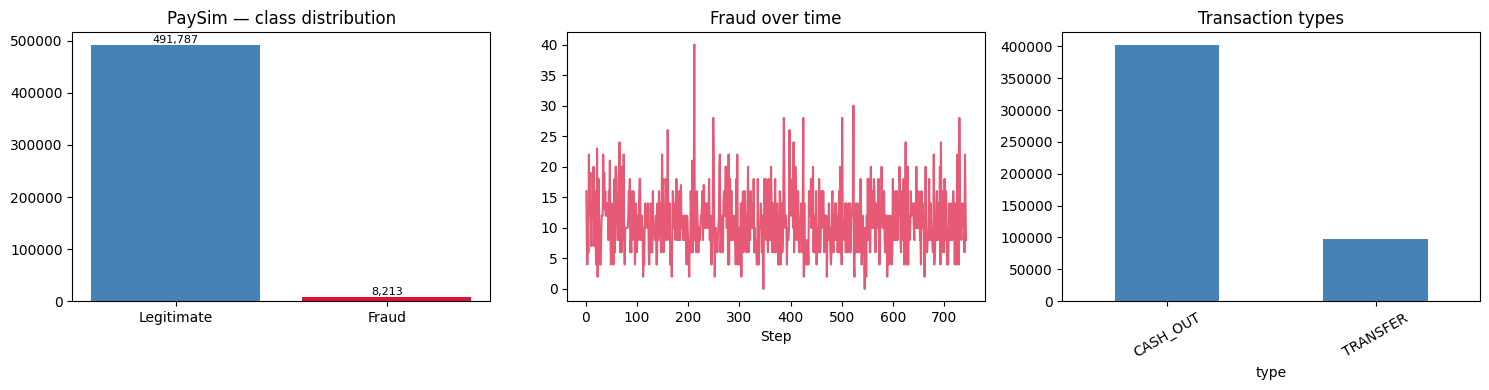

  ✅ EDA plot → /content/drive/MyDrive/FraudDetection_Research/datasets/plots/PaySim_eda.png


In [ ]:
plot_eda(df_pay_work, pay_cols['label'], pay_cols['time'],
         pay_cols['type'], 'PaySim', PLOTS_DIR)

In [ ]:
print('=== Building PaySim main graph ===')
paysim_graph, paysim_acc_df, paysim_acc2idx = build_graph(
    df_pay_work,
    sender_col   = pay_cols['sender'],
    receiver_col = pay_cols['receiver'],
    label_col    = pay_cols['label'],
    amount_col   = pay_cols['amount'],
    time_col     = pay_cols['time'],
    type_col     = pay_cols['type'],
)

=== Building PaySim main graph ===
  Building graph...
  nodes=764,523  edges=500,000  node_feats=12  edge_feats=3  fraud_nodes=16,382 (2.14%)


In [ ]:
print('=== Building PaySim temporal graphs (concept drift windows) ===')
paysim_temporal = build_temporal_graphs(
    df_pay_work,
    sender_col   = pay_cols['sender'],
    receiver_col = pay_cols['receiver'],
    label_col    = pay_cols['label'],
    amount_col   = pay_cols['amount'],
    time_col     = pay_cols['time'],
    type_col     = pay_cols['type'],
    n_splits     = N_TEMPORAL_SPLITS,
)

=== Building PaySim temporal graphs (concept drift windows) ===
  Window 1 | steps 1–248 | 251,275 txns | fraud: 2,791
  Building graph...
  nodes=384,518  edges=251,275  node_feats=12  edge_feats=3  fraud_nodes=5,570 (1.45%)
  Window 2 | steps 248–496 | 223,808 txns | fraud: 2,718
  Building graph...
  nodes=398,928  edges=223,808  node_feats=12  edge_feats=3  fraud_nodes=5,431 (1.36%)
  Window 3 | steps 496–744 | 24,917 txns | fraud: 2,704
  Building graph...
  nodes=49,344  edges=24,917  node_feats=12  edge_feats=3  fraud_nodes=5,406 (10.96%)


In [ ]:
print(f'=== Saving PaySim → {PAYSIM_OUT_DIR} ===')
paysim_meta = save_to_drive(
    paysim_graph, paysim_temporal, paysim_acc_df,
    PAYSIM_OUT_DIR, 'paysim'
)

=== Saving PaySim → /content/drive/MyDrive/FraudDetection_Research/datasets/paysim ===
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/paysim/paysim_graph.pt
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/paysim/paysim_temporal_w1.pt
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/paysim/paysim_temporal_w2.pt
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/paysim/paysim_temporal_w3.pt
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/paysim/paysim_account_features.csv
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/paysim/paysim_metadata.json


---
## PART 2 — MoMTSim

In [ ]:
print('Loading MoMTSim...')
df_mom = pd.read_csv(MOMTSIM_CSV)
print(f'Shape   : {df_mom.shape}')
print(f'Columns : {df_mom.columns.tolist()}')
df_mom.head(3)

Loading MoMTSim...
Shape   : (1720181, 10)
Columns : ['step', 'transactionType', 'amount', 'initiator', 'oldBalInitiator', 'newBalInitiator', 'recipient', 'oldBalRecipient', 'newBalRecipient', 'isFraud']


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,0,PAYMENT,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0
2,0,PAYMENT,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0


In [ ]:
mom_cols = detect_columns(df_mom, 'MoMTSim')

# ── Override any column not found automatically ──
# mom_cols['sender']   = 'nameOrig'
# mom_cols['receiver'] = 'nameDest'
# mom_cols['label']    = 'isFraud'
# mom_cols['amount']   = 'amount'
# mom_cols['time']     = 'step'
# mom_cols['type']     = 'type'


=== MoMTSim — column detection ===
  sender    : initiator
  receiver  : recipient
  label     : isFraud
  amount    : amount
  time      : step
  type      : transactionType

✅ All critical columns detected.


Subsampled: 300,000 rows | fraud: 175,518 (58.51%)


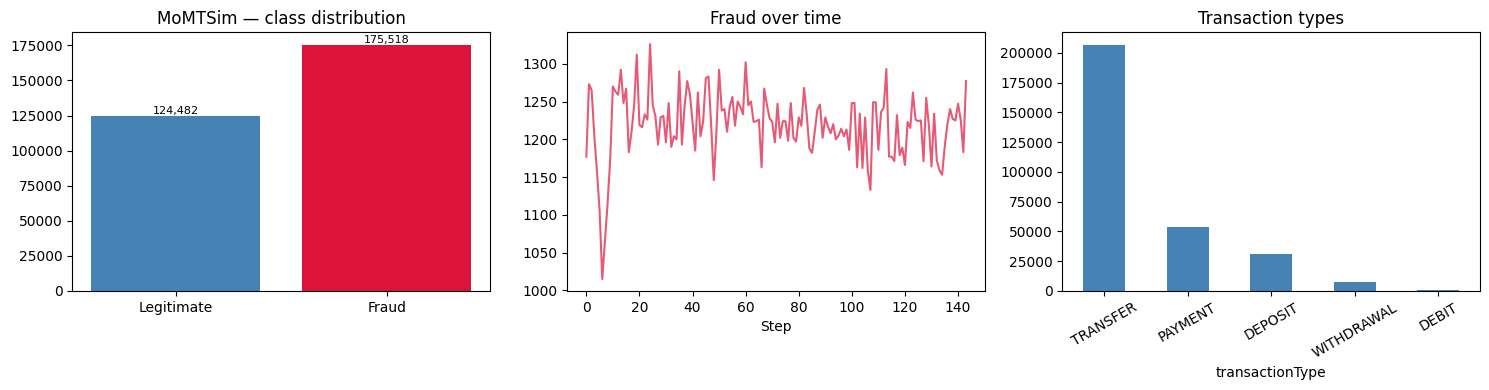

  ✅ EDA plot → /content/drive/MyDrive/FraudDetection_Research/datasets/plots/MoMTSim_eda.png


In [ ]:
df_mom_work = stratified_subsample(df_mom, mom_cols['label'], MOMTSIM_SUBSAMPLE_SIZE)

plot_eda(df_mom_work, mom_cols['label'], mom_cols['time'],
         mom_cols['type'], 'MoMTSim', PLOTS_DIR)

In [ ]:
print('=== Building MoMTSim main graph ===')
momtsim_graph, momtsim_acc_df, momtsim_acc2idx = build_graph(
    df_mom_work,
    sender_col   = mom_cols['sender'],
    receiver_col = mom_cols['receiver'],
    label_col    = mom_cols['label'],
    amount_col   = mom_cols['amount'],
    time_col     = mom_cols['time'],
    type_col     = mom_cols['type'],
)

=== Building MoMTSim main graph ===
  Building graph...
  nodes=23,062  edges=300,000  node_feats=12  edge_feats=3  fraud_nodes=15,286 (66.28%)


In [ ]:
print('=== Building MoMTSim temporal graphs ===')
momtsim_temporal = build_temporal_graphs(
    df_mom_work,
    sender_col   = mom_cols['sender'],
    receiver_col = mom_cols['receiver'],
    label_col    = mom_cols['label'],
    amount_col   = mom_cols['amount'],
    time_col     = mom_cols['time'],
    type_col     = mom_cols['type'],
    n_splits     = N_TEMPORAL_SPLITS,
)

=== Building MoMTSim temporal graphs ===
  Window 1 | steps 0–48 | 118,176 txns | fraud: 58,633
  Building graph...
  nodes=22,163  edges=118,176  node_feats=12  edge_feats=3  fraud_nodes=13,906 (62.74%)
  Window 2 | steps 48–95 | 86,767 txns | fraud: 58,808
  Building graph...
  nodes=18,472  edges=86,767  node_feats=12  edge_feats=3  fraud_nodes=13,046 (70.63%)
  Window 3 | steps 95–144 | 95,057 txns | fraud: 58,077
  Building graph...
  nodes=19,072  edges=95,057  node_feats=12  edge_feats=3  fraud_nodes=12,770 (66.96%)


In [ ]:
print(f'=== Saving MoMTSim → {MOMTSIM_OUT_DIR} ===')
momtsim_meta = save_to_drive(
    momtsim_graph, momtsim_temporal, momtsim_acc_df,
    MOMTSIM_OUT_DIR, 'momtsim'
)

=== Saving MoMTSim → /content/drive/MyDrive/FraudDetection_Research/datasets/momtsim ===
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/momtsim/momtsim_graph.pt
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/momtsim/momtsim_temporal_w1.pt
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/momtsim/momtsim_temporal_w2.pt
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/momtsim/momtsim_temporal_w3.pt
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/momtsim/momtsim_account_features.csv
  ✅ /content/drive/MyDrive/FraudDetection_Research/datasets/momtsim/momtsim_metadata.json


---
## PART 3 — Summary & Drive Folder Structure

In [ ]:
print('=' * 56)
print(f'{"Metric":<26} {"PaySim":>14} {"MoMTSim":>14}')
print('=' * 56)
fields = [
    ('Nodes',            'num_nodes'),
    ('Edges',            'num_edges'),
    ('Node features',    'num_node_feats'),
    ('Edge features',    'num_edge_feats'),
    ('Fraud nodes',      'num_fraud_nodes'),
    ('Fraud %',          'fraud_pct'),
    ('Train nodes',      'train_nodes'),
    ('Val nodes',        'val_nodes'),
    ('Test nodes',       'test_nodes'),
    ('Temporal windows', 'temporal_windows'),
]
for label, key in fields:
    print(f'{label:<26} {str(paysim_meta[key]):>14} {str(momtsim_meta[key]):>14}')
print('=' * 56)

print(f'\n📁 Drive folder structure:')
print(f'  {DRIVE_BASE}/')
for folder, ds in [(PAYSIM_OUT_DIR,'paysim'),(MOMTSIM_OUT_DIR,'momtsim')]:
    print(f'  ├── {os.path.basename(folder)}/')
    for f in sorted(os.listdir(folder)):
        kb = os.path.getsize(os.path.join(folder,f))//1024
        print(f'  │     {f:<46} {kb:>6} KB')
print(f'  └── plots/')
for f in sorted(os.listdir(PLOTS_DIR)):
    print(f'        {f}')

Metric                             PaySim        MoMTSim
Nodes                              764523          23062
Edges                              500000         300000
Node features                          12             12
Edge features                           3              3
Fraud nodes                         16382          15286
Fraud %                             2.143         66.282
Train nodes                        535166          16143
Val nodes                          114678           3459
Test nodes                         114679           3460
Temporal windows                        3              3

📁 Drive folder structure:
  /content/drive/MyDrive/FraudDetection_Research/datasets/
  ├── paysim/
  │     paysim_account_features.csv                     64656 KB
  │     paysim_graph.pt                                 57724 KB
  │     paysim_metadata.json                                0 KB
  │     paysim_temporal_w1.pt                           29029 KB
  │     paysi

In [ ]:
# ── Reload from Drive and verify integrity ──
print('=== Sanity check: reloading graphs from Drive ===\n')
for name, folder, ds in [('PaySim',PAYSIM_OUT_DIR,'paysim'),('MoMTSim',MOMTSIM_OUT_DIR,'momtsim')]:
    g = torch.load(os.path.join(folder, f'{ds}_graph.pt'),weights_only=False)
    nan_x = torch.isnan(g.x).any().item()
    status = '✅ READY' if not nan_x else '⚠️  NaN found'
    print(f'{name}:')
    print(f'  x          : {g.x.shape}')
    print(f'  edge_index : {g.edge_index.shape}')
    print(f'  edge_attr  : {g.edge_attr.shape}')
    print(f'  y          : {g.y.shape} | classes: {g.y.unique().tolist()}')
    print(f'  masks      : train={g.train_mask.sum()} val={g.val_mask.sum()} test={g.test_mask.sum()}')
    print(f'  Status     : {status}\n')

print('🎉 All done! Load in your GNN notebooks with:')
print(f'  torch.load("{PAYSIM_OUT_DIR}/paysim_graph.pt")')
print(f'  torch.load("{MOMTSIM_OUT_DIR}/momtsim_graph.pt")')

=== Sanity check: reloading graphs from Drive ===

PaySim:
  x          : torch.Size([764523, 12])
  edge_index : torch.Size([2, 500000])
  edge_attr  : torch.Size([500000, 3])
  y          : torch.Size([764523]) | classes: [0, 1]
  masks      : train=535166 val=114678 test=114679
  Status     : ✅ READY

MoMTSim:
  x          : torch.Size([23062, 12])
  edge_index : torch.Size([2, 300000])
  edge_attr  : torch.Size([300000, 3])
  y          : torch.Size([23062]) | classes: [0, 1]
  masks      : train=16143 val=3459 test=3460
  Status     : ✅ READY

🎉 All done! Load in your GNN notebooks with:
  torch.load("/content/drive/MyDrive/FraudDetection_Research/datasets/paysim/paysim_graph.pt")
  torch.load("/content/drive/MyDrive/FraudDetection_Research/datasets/momtsim/momtsim_graph.pt")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted.


In [ ]:
import os

# ══════════════════════════════════════════════════════════════════
#  EDIT ONLY THIS CELL — all paths are derived from DRIVE_BASE
# ══════════════════════════════════════════════════════════════════

# Root folder in Drive — all graph datasets live here
DRIVE_BASE      = '/content/drive/MyDrive/FraudDetection_Research/datasets'

# Pre-built .pt graphs (from graph construction notebook)
PAYSIM_PT       = os.path.join(DRIVE_BASE, 'paysim/paysim_graph.pt')
MOMTSIM_PT      = os.path.join(DRIVE_BASE, 'momtsim/momtsim_graph.pt')

# Temporal graphs for concept drift (Phase 4)
PAYSIM_TEMPORAL  = [os.path.join(DRIVE_BASE, f'paysim/paysim_temporal_w{i}.pt') for i in range(1,4)]
MOMTSIM_TEMPORAL = [os.path.join(DRIVE_BASE, f'momtsim/momtsim_temporal_w{i}.pt') for i in range(1,4)]

# Where Elliptic and T-Finance raw data will be cached by PyG
PYG_CACHE       = os.path.join(DRIVE_BASE, 'pyg_cache')
os.makedirs(PYG_CACHE, exist_ok=True)

# Output: unified dataset bundle saved here
ALL_DATASETS_PT = os.path.join(DRIVE_BASE, 'all_datasets.pt')

print(f'Drive base   : {DRIVE_BASE}')
print(f'PyG cache    : {PYG_CACHE}')
print(f'Output bundle: {ALL_DATASETS_PT}')

Drive base   : /content/drive/MyDrive/FraudDetection_Research/datasets
PyG cache    : /content/drive/MyDrive/FraudDetection_Research/datasets/pyg_cache
Output bundle: /content/drive/MyDrive/FraudDetection_Research/datasets/all_datasets.pt


In [ ]:
import torch
print(f'PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}')

!pip install torch_geometric -q
!pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html -q
!pip install ogb scikit-learn pandas numpy matplotlib -q

print('\n✅ All dependencies installed.')

PyTorch: 2.10.0+cu128 | CUDA: True

✅ All dependencies installed.


In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports OK | device: {device}')

✅ Imports OK | device: cuda


In [ ]:
def load_pt_graph(path, name):
    print(f'Loading {name}...', end=' ')
    assert os.path.exists(path), f'File not found: {path}'
    g = torch.load(path, weights_only=False)
    print(f'nodes={g.num_nodes:,}  edges={g.num_edges:,}  '
          f'fraud={g.y.sum().item():,} ({g.y.float().mean().item()*100:.2f}%)  ✅')
    return g

paysim_data  = load_pt_graph(PAYSIM_PT,  'PaySim')
momtsim_data = load_pt_graph(MOMTSIM_PT, 'MoMTSim')

# Load temporal graphs
paysim_temporal, momtsim_temporal = [], []
for i, p in enumerate(PAYSIM_TEMPORAL):
    if os.path.exists(p):
        paysim_temporal.append(torch.load(p, weights_only=False))
        print(f'  PaySim temporal w{i+1}: nodes={paysim_temporal[-1].num_nodes:,}')

for i, p in enumerate(MOMTSIM_TEMPORAL):
    if os.path.exists(p):
        momtsim_temporal.append(torch.load(p, weights_only=False))
        print(f'  MoMTSim temporal w{i+1}: nodes={momtsim_temporal[-1].num_nodes:,}')

Loading PaySim... nodes=764,523  edges=500,000  fraud=16,382 (2.14%)  ✅
Loading MoMTSim... nodes=23,062  edges=300,000  fraud=15,286 (66.28%)  ✅
  PaySim temporal w1: nodes=384,518
  PaySim temporal w2: nodes=398,928
  PaySim temporal w3: nodes=49,344
  MoMTSim temporal w1: nodes=22,163
  MoMTSim temporal w2: nodes=18,472
  MoMTSim temporal w3: nodes=19,072


In [ ]:
from torch_geometric.datasets import EllipticBitcoinDataset

print('Loading Elliptic Bitcoin dataset (downloads if not cached)...')
elliptic_raw = EllipticBitcoinDataset(root=os.path.join(PYG_CACHE, 'elliptic'))

print(f'Time steps (graphs): {len(elliptic_raw)}')
print(f'Sample graph[0]    : {elliptic_raw[0]}')

Loading Elliptic Bitcoin dataset (downloads if not cached)...
Time steps (graphs): 1
Sample graph[0]    : Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])


In [ ]:
# Merge all 49 time steps into one unified graph
all_x, all_y, all_ei = [], [], []
node_offset = 0
elliptic_time_masks = []  # tracks which nodes belong to which time step

for t, g in enumerate(elliptic_raw):
    all_x.append(g.x)
    all_y.append(g.y)
    all_ei.append(g.edge_index + node_offset)
    elliptic_time_masks.append((node_offset, node_offset + g.num_nodes, t))
    node_offset += g.num_nodes

x_ell  = torch.cat(all_x, dim=0)
y_ell  = torch.cat(all_y, dim=0)
ei_ell = torch.cat(all_ei, dim=1)

# Elliptic labels: 0=licit, 1=illicit, 2=unknown
# Replace unknown (2) with -1 so we can mask them out during training
y_ell[y_ell == 2] = -1

# Build stratified train/val/test masks on labelled nodes only
labelled_idx = (y_ell != -1).nonzero(as_tuple=True)[0].numpy()
y_lab        = y_ell[labelled_idx].numpy()

tr, te = train_test_split(labelled_idx, test_size=0.30, random_state=42, stratify=y_lab)
va, te = train_test_split(te, test_size=0.50, random_state=42, stratify=y_ell[te].numpy())

n_ell = x_ell.shape[0]
train_mask_e = torch.zeros(n_ell, dtype=torch.bool)
val_mask_e   = torch.zeros(n_ell, dtype=torch.bool)
test_mask_e  = torch.zeros(n_ell, dtype=torch.bool)
train_mask_e[tr] = True
val_mask_e[va]   = True
test_mask_e[te]  = True

elliptic_data = Data(
    x=x_ell, edge_index=ei_ell, y=y_ell,
    train_mask=train_mask_e,
    val_mask=val_mask_e,
    test_mask=test_mask_e
)
elliptic_data.time_masks = elliptic_time_masks

print(f'Unified Elliptic graph:')
print(f'  nodes     : {elliptic_data.num_nodes:,}')
print(f'  edges     : {elliptic_data.num_edges:,}')
print(f'  features  : {elliptic_data.num_node_features}')
print(f'  illicit   : {(y_ell==1).sum().item():,} ({(y_ell==1).float().mean().item()*100:.2f}%)')
print(f'  unknown   : {(y_ell==-1).sum().item():,} (masked out)')
print(f'  time steps: {len(elliptic_raw)}')
print('✅ Elliptic loaded.')

Unified Elliptic graph:
  nodes     : 203,769
  edges     : 234,355
  features  : 165
  illicit   : 4,545 (2.23%)
  unknown   : 157,205 (masked out)
  time steps: 1
✅ Elliptic loaded.


In [ ]:
TFINANCE_CACHE = os.path.join(PYG_CACHE, 'tfinance')
os.makedirs(TFINANCE_CACHE, exist_ok=True)

!pip install gdown -q
import gdown

tfinance_zip = os.path.join(TFINANCE_CACHE, 'tfinance.zip')

if not os.path.exists(tfinance_zip):
    print('Downloading T-Finance from GADBench...')
    gdown.download(
        'https://drive.google.com/uc?id=1ElNahIoFLagmSANVtMBQHuCPcFuHfA4d',
        tfinance_zip,
        quiet=False
    )
    print('Download complete.')
else:
    print('T-Finance zip already downloaded.')

!unzip -q {tfinance_zip} -d {TFINANCE_CACHE}
print('Extracted.')

FileURLRetrievalError: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1ElNahIoFLagmSANVtMBQHuCPcFuHfA4d

but Gdown can't. Please check connections and permissions.

In [ ]:
DATASETS = {
    'elliptic' : {
        'graph'    : elliptic_data,
        'temporal' : elliptic_raw,       # 49 per-timestep graphs
        'name'     : 'Elliptic (Bitcoin)',
        'domain'   : 'Cryptocurrency',
    },
    'paysim'   : {
        'graph'    : paysim_data,
        'temporal' : paysim_temporal,    # 3 time-window graphs
        'name'     : 'PaySim (Mobile Money)',
        'domain'   : 'Mobile payments / UPI-analog',
    },
    'momtsim'  : {
        'graph'    : momtsim_data,
        'temporal' : momtsim_temporal,
        'name'     : 'MoMTSim (Mobile Money)',
        'domain'   : 'Mobile payments / UPI-analog',
    },
}

print('=' * 74)
print(f'{"Dataset":<22} {"Nodes":>10} {"Edges":>12} {"Feats":>6} {"Fraud":>8} {"Fraud%":>8}')
print('=' * 74)
for key, d in DATASETS.items():
    g        = d['graph']
    labelled = g.y[g.y != -1]
    fraud_n  = (labelled == 1).sum().item()
    fraud_p  = fraud_n / len(labelled) * 100
    print(f'{d["name"]:<22} {g.num_nodes:>10,} {g.num_edges:>12,} '
          f'{g.num_node_features:>6} {fraud_n:>8,} {fraud_p:>7.2f}%')
print('=' * 74)

Dataset                     Nodes        Edges  Feats    Fraud   Fraud%
Elliptic (Bitcoin)        203,769      234,355    165    4,545    9.76%
PaySim (Mobile Money)     764,523      500,000     12   16,382    2.14%
MoMTSim (Mobile Money)     23,062      300,000     12   15,286   66.28%


In [ ]:
import os, torch
import numpy as np
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

TFINANCE_CACHE = os.path.join(PYG_CACHE, 'tfinance')
os.makedirs(TFINANCE_CACHE, exist_ok=True)

GAD_ZIP   = os.path.join(TFINANCE_CACHE, 'gadbench_datasets.zip')
GAD_DIR   = os.path.join(TFINANCE_CACHE, 'datasets')
TFINANCE_SAVE_PT = os.path.join(DRIVE_BASE, 'tfinance_graph.pt')

# ── Step 1: Download the full GADBench zip (contains T-Finance) ──
if not os.path.exists(GAD_ZIP):
    print('Downloading GADBench datasets zip...')
    !gdown "https://drive.google.com/file/d/1txzXrzwBBAOEATXmfKzMUUKaXh6PJeR1/view?usp=sharing" \
           --fuzzy -O {GAD_ZIP}
else:
    print('Zip already downloaded.')

# ── Step 2: Unzip ──
if not os.path.exists(GAD_DIR):
    print('Extracting...')
    !unzip -q {GAD_ZIP} -d {TFINANCE_CACHE}
    print('Extracted.')

# ── Step 3: Check what files are inside ──
print('\nFiles in extracted folder:')
for root, dirs, files in os.walk(TFINANCE_CACHE):
    for f in files:
        print(' ', os.path.join(root, f))

Downloading...
From (original): https://drive.google.com/uc?id=1txzXrzwBBAOEATXmfKzMUUKaXh6PJeR1
From (redirected): https://drive.google.com/uc?id=1txzXrzwBBAOEATXmfKzMUUKaXh6PJeR1&confirm=t&uuid=250de19c-6808-465d-a644-47356d7fe627
To: /content/drive/MyDrive/FraudDetection_Research/datasets/pyg_cache/tfinance/gadbench_datasets.zip
100% 757M/757M [00:10<00:00, 74.9MB/s]
Extracting...
Extracted.

Files in extracted folder:
  /content/drive/MyDrive/FraudDetection_Research/datasets/pyg_cache/tfinance/gadbench_datasets.zip
  /content/drive/MyDrive/FraudDetection_Research/datasets/pyg_cache/tfinance/datasets/amazon
  /content/drive/MyDrive/FraudDetection_Research/datasets/pyg_cache/tfinance/datasets/questions
  /content/drive/MyDrive/FraudDetection_Research/datasets/pyg_cache/tfinance/datasets/reddit
  /content/drive/MyDrive/FraudDetection_Research/datasets/pyg_cache/tfinance/datasets/tfinance
  /content/drive/MyDrive/FraudDetection_Research/datasets/pyg_cache/tfinance/datasets/tolokers
  /

In [ ]:
# Check what type of file this actually is
fpath = '/content/drive/MyDrive/FraudDetection_Research/datasets/pyg_cache/tfinance/datasets/tfinance'

# Read first few bytes to identify file type
with open(fpath, 'rb') as f:
    header = f.read(20)
print('First 20 bytes (hex):', header.hex())
print('First 20 bytes (raw):', header)

# Check file size
size_mb = os.path.getsize(fpath) / 1024 / 1024
print(f'File size: {size_mb:.2f} MB')

# Try listing the directory to see if there are more files
import os
parent = os.path.dirname(fpath)
print('\nAll files in directory:')
for f in os.listdir(parent):
    fp = os.path.join(parent, f)
    print(f'  {f}  ({os.path.getsize(fp)/1024:.1f} KB)')

First 20 bytes (hex): 3fa1b446f04f2edd020000000000000002000000
First 20 bytes (raw): b'?\xa1\xb4F\xf0O.\xdd\x02\x00\x00\x00\x00\x00\x00\x00\x02\x00\x00\x00'
File size: 976.45 MB

All files in directory:
  amazon  (209552.2 KB)
  hetero  (4.0 KB)
  questions  (63146.8 KB)
  reddit  (7418.4 KB)
  tfinance  (999885.2 KB)
  tolokers  (7465.1 KB)
  tsocial  (5449808.7 KB)
  weibo  (23454.7 KB)
  yelp  (191058.2 KB)


In [ ]:
DATASETS = {
    'elliptic' : {
        'graph'   : elliptic_data,
        'temporal': elliptic_raw,
        'name'    : 'Elliptic (Bitcoin)',
        'domain'  : 'Cryptocurrency',
    },
    'paysim'   : {
        'graph'   : paysim_data,
        'temporal': paysim_temporal,
        'name'    : 'PaySim (Mobile Money)',
        'domain'  : 'Mobile payments / UPI-analog',
    },
    'momtsim'  : {
        'graph'   : momtsim_data,
        'temporal': momtsim_temporal,
        'name'    : 'MoMTSim (Mobile Money)',
        'domain'  : 'Mobile payments / UPI-analog',
    },
}

print('=' * 70)
print(f'{"Dataset":<24} {"Nodes":>10} {"Edges":>12} {"Feats":>6} {"Fraud":>8} {"Fraud%":>8}')
print('=' * 70)
for key, d in DATASETS.items():
    g        = d['graph']
    labelled = g.y[g.y != -1]
    fraud_n  = (labelled == 1).sum().item()
    fraud_p  = fraud_n / len(labelled) * 100
    print(f'{d["name"]:<24} {g.num_nodes:>10,} {g.num_edges:>12,} '
          f'{g.num_node_features:>6} {fraud_n:>8,} {fraud_p:>7.2f}%')
print('=' * 70)
print(f'\n✅ {len(DATASETS)} datasets registered.')

Dataset                       Nodes        Edges  Feats    Fraud   Fraud%
Elliptic (Bitcoin)          203,769      234,355    165    4,545    9.76%
PaySim (Mobile Money)       764,523      500,000     12   16,382    2.14%
MoMTSim (Mobile Money)       23,062      300,000     12   15,286   66.28%

✅ 3 datasets registered.


In [ ]:
bundle = {
    'datasets'  : DATASETS,
    'device'    : str(device),
    'drive_base': DRIVE_BASE,
}
torch.save(bundle, ALL_DATASETS_PT)

size_mb = os.path.getsize(ALL_DATASETS_PT) / 1024 / 1024
print(f'✅ Bundle saved → {ALL_DATASETS_PT}  ({size_mb:.1f} MB)')
print('\nLoad in any experiment notebook with:')
print('  bundle   = torch.load("<path>/all_datasets.pt", weights_only=False)')
print('  DATASETS = bundle["datasets"]')

✅ Bundle saved → /content/drive/MyDrive/FraudDetection_Research/datasets/all_datasets.pt  (405.0 MB)

Load in any experiment notebook with:
  bundle   = torch.load("<path>/all_datasets.pt", weights_only=False)
  DATASETS = bundle["datasets"]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch_geometric imbalanced-learn xgboost scikit-learn -q

print('✅ Done.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Done.


In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score,
                              ConfusionMatrixDisplay, confusion_matrix)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports OK | device: {device}')

✅ Imports OK | device: cuda


In [ ]:
DRIVE_BASE  = '/content/drive/MyDrive/FraudDetection_Research/datasets'
RESULTS_DIR = os.path.join(DRIVE_BASE, '../results/phase1')
os.makedirs(RESULTS_DIR, exist_ok=True)

bundle   = torch.load(os.path.join(DRIVE_BASE, 'all_datasets.pt'), weights_only=False)
DATASETS = bundle['datasets']

print(f'✅ {len(DATASETS)} datasets loaded')
print(f'Results will be saved → {RESULTS_DIR}')
for k, d in DATASETS.items():
    g   = d['graph']
    lab = g.y[g.y != -1]
    print(f'  {k:<12} nodes={g.num_nodes:,}  fraud={(lab==1).sum().item():,}')

✅ 3 datasets loaded
Results will be saved → /content/drive/MyDrive/FraudDetection_Research/datasets/../results/phase1
  elliptic     nodes=203,769  fraud=4,545
  paysim       nodes=764,523  fraud=16,382
  momtsim      nodes=23,062  fraud=15,286


In [ ]:
def graph_to_tabular(ds_name, ds):
    """
    Extract node features + labels as numpy arrays from a PyG graph.
    Filters out unlabelled nodes (y == -1, Elliptic unknowns).
    Returns X_train, X_test, y_train, y_test.
    """
    g   = ds['graph']
    X   = g.x.numpy()
    y   = g.y.numpy()

    # Keep only labelled nodes
    lab      = y != -1
    X, y     = X[lab], y[lab]
    tr_mask  = g.train_mask.numpy()[lab]
    te_mask  = g.test_mask.numpy()[lab]

    X_tr, y_tr = X[tr_mask],  y[tr_mask]
    X_te, y_te = X[te_mask],  y[te_mask]

    print(f'\n{ds_name}:')
    print(f'  Train: {len(y_tr):,} samples | fraud: {y_tr.sum():,} ({y_tr.mean()*100:.2f}%)')
    print(f'  Test : {len(y_te):,} samples | fraud: {y_te.sum():,} ({y_te.mean()*100:.2f}%)')
    return X_tr, X_te, y_tr, y_te

print('✅ Helper defined.')

✅ Helper defined.


In [ ]:
def evaluate(model, X_te, y_te, model_name, ds_name):
    """Compute AUC-ROC, AUPRC, F1, Precision, Recall."""
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_te)[:, 1]
    else:
        score = model.decision_function(X_te)
        proba = (score - score.min()) / (score.max() - score.min() + 1e-8)

    pred = model.predict(X_te)

    return {
        'model'    : model_name,
        'dataset'  : ds_name,
        'AUC-ROC'  : round(roc_auc_score(y_te, proba),              4),
        'AUPRC'    : round(average_precision_score(y_te, proba),     4),
        'F1'       : round(f1_score(y_te, pred, zero_division=0),    4),
        'Precision': round(precision_score(y_te, pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, pred, zero_division=0),    4),
    }

print('✅ Evaluate function defined.')

✅ Evaluate function defined.


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        n_jobs=-1, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, scale_pos_weight=99,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        max_iter=200, early_stopping=True,
        random_state=42
    ),
}

print('✅ Models defined:')
for name in models:
    print(f'  - {name}')

✅ Models defined:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - MLP


In [ ]:
all_results = []

for ds_name, ds in DATASETS.items():
    print(f'\n{"="*55}')
    print(f'  Dataset: {ds["name"]}')
    print(f'{"="*55}')

    X_tr, X_te, y_tr, y_te = graph_to_tabular(ds_name, ds)

    # Apply SMOTE to training set to handle class imbalance
    print(f'\n  Applying SMOTE...')
    try:
        k = min(5, int(y_tr.sum()) - 1)
        sm = SMOTE(random_state=42, k_neighbors=k)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)
        print(f'  Before: {len(y_tr):,} | After SMOTE: {len(y_tr_sm):,}')
    except Exception as e:
        print(f'  SMOTE skipped ({e}) — using original')
        X_tr_sm, y_tr_sm = X_tr, y_tr

    # Train and evaluate each model
    print()
    for m_name, model in models.items():
        print(f'  Training {m_name}...', end=' ')
        model.fit(X_tr_sm, y_tr_sm)
        res = evaluate(model, X_te, y_te, m_name, ds_name)
        all_results.append(res)
        print(f'AUC-ROC={res["AUC-ROC"]:.4f}  '
              f'AUPRC={res["AUPRC"]:.4f}  '
              f'F1={res["F1"]:.4f}')

print('\n✅ All baselines complete.')


  Dataset: Elliptic (Bitcoin)

elliptic:
  Train: 32,594 samples | fraud: 3,181 (9.76%)
  Test : 6,985 samples | fraud: 682 (9.76%)

  Applying SMOTE...
  Before: 32,594 | After SMOTE: 58,826

  Training Logistic Regression... AUC-ROC=0.9683  AUPRC=0.7988  F1=0.6484
  Training Random Forest... AUC-ROC=0.9965  AUPRC=0.9824  F1=0.9496
  Training XGBoost... AUC-ROC=0.9961  AUPRC=0.9846  F1=0.9454
  Training MLP... AUC-ROC=0.9792  AUPRC=0.9171  F1=0.8905

  Dataset: PaySim (Mobile Money)

paysim:
  Train: 535,166 samples | fraud: 11,467 (2.14%)
  Test : 114,679 samples | fraud: 2,458 (2.14%)

  Applying SMOTE...
  Before: 535,166 | After SMOTE: 1,047,398

  Training Logistic Regression... AUC-ROC=0.9468  AUPRC=0.6308  F1=0.1707
  Training Random Forest... AUC-ROC=0.9293  AUPRC=0.3763  F1=0.2485
  Training XGBoost... AUC-ROC=0.9449  AUPRC=0.6679  F1=0.1199
  Training MLP... AUC-ROC=0.9478  AUPRC=0.6736  F1=0.2328

  Dataset: MoMTSim (Mobile Money)

momtsim:
  Train: 16,143 samples | fraud:

In [ ]:
df_res = pd.DataFrame(all_results)

print('\n=== Phase 1 — Baseline Results ===\n')
print(df_res[['dataset','model','AUC-ROC','AUPRC','F1','Precision','Recall']]
      .sort_values(['dataset','AUPRC'], ascending=[True, False])
      .to_string(index=False))

# Save to Drive
csv_path = os.path.join(RESULTS_DIR, 'phase1_baseline_results.csv')
df_res.to_csv(csv_path, index=False)
print(f'\n✅ Saved → {csv_path}')

# Best model per dataset
print('\nBest model per dataset (by AUPRC):')
best = df_res.loc[df_res.groupby('dataset')['AUPRC'].idxmax()]
print(best[['dataset','model','AUC-ROC','AUPRC','F1']].to_string(index=False))


=== Phase 1 — Baseline Results ===

 dataset               model  AUC-ROC  AUPRC     F1  Precision  Recall
elliptic             XGBoost   0.9961 0.9846 0.9454     0.9392  0.9516
elliptic       Random Forest   0.9965 0.9824 0.9496     0.9904  0.9120
elliptic                 MLP   0.9792 0.9171 0.8905     0.8866  0.8944
elliptic Logistic Regression   0.9683 0.7988 0.6484     0.5008  0.9194
 momtsim       Random Forest   1.0000 1.0000 0.9987     0.9991  0.9983
 momtsim             XGBoost   1.0000 1.0000 0.9991     0.9987  0.9996
 momtsim                 MLP   1.0000 1.0000 0.9976     0.9983  0.9969
 momtsim Logistic Regression   0.9990 0.9995 0.9945     0.9965  0.9926
  paysim                 MLP   0.9478 0.6736 0.2328     0.1358  0.8153
  paysim             XGBoost   0.9449 0.6679 0.1199     0.0639  0.9658
  paysim Logistic Regression   0.9468 0.6308 0.1707     0.0947  0.8674
  paysim       Random Forest   0.9293 0.3763 0.2485     0.1479  0.7779

✅ Saved → /content/drive/MyDrive/FraudD

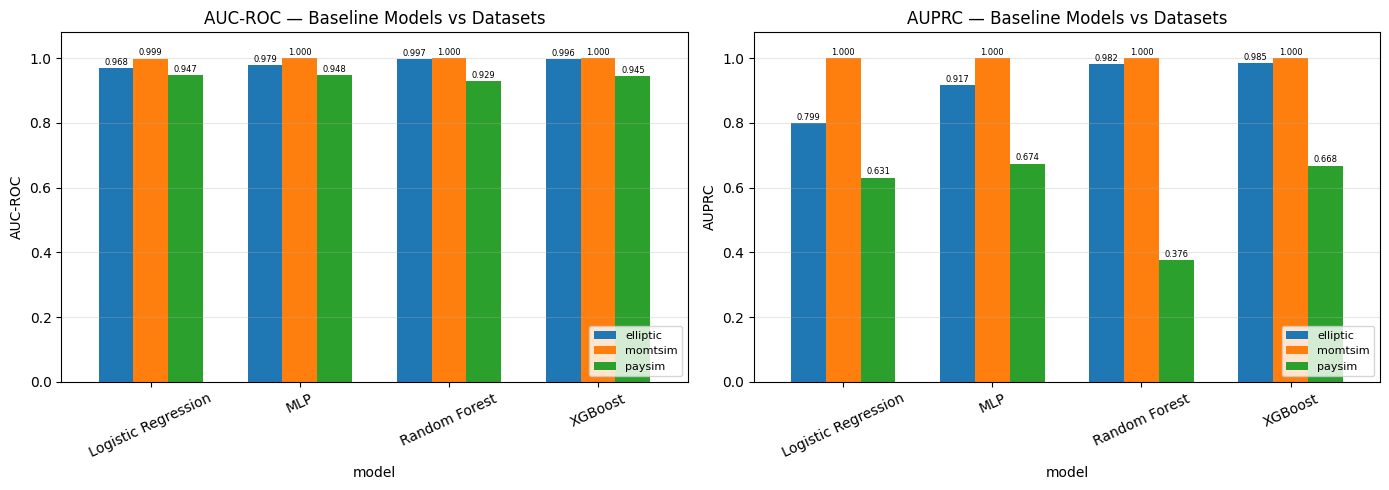

✅ Plot saved → /content/drive/MyDrive/FraudDetection_Research/datasets/../results/phase1/phase1_auc_auprc_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['AUC-ROC', 'AUPRC']):
    pivot = df_res.pivot(index='model', columns='dataset', values=metric)
    bars  = pivot.plot(kind='bar', ax=ax, rot=25, width=0.7)
    ax.set_title(f'{metric} — Baseline Models vs Datasets', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.08)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=6, padding=1)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'phase1_auc_auprc_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Plot saved → {plot_path}')


elliptic:
  Train: 32,594 samples | fraud: 3,181 (9.76%)
  Test : 6,985 samples | fraud: 682 (9.76%)

paysim:
  Train: 535,166 samples | fraud: 11,467 (2.14%)
  Test : 114,679 samples | fraud: 2,458 (2.14%)

momtsim:
  Train: 16,143 samples | fraud: 10,700 (66.28%)
  Test : 3,460 samples | fraud: 2,293 (66.27%)


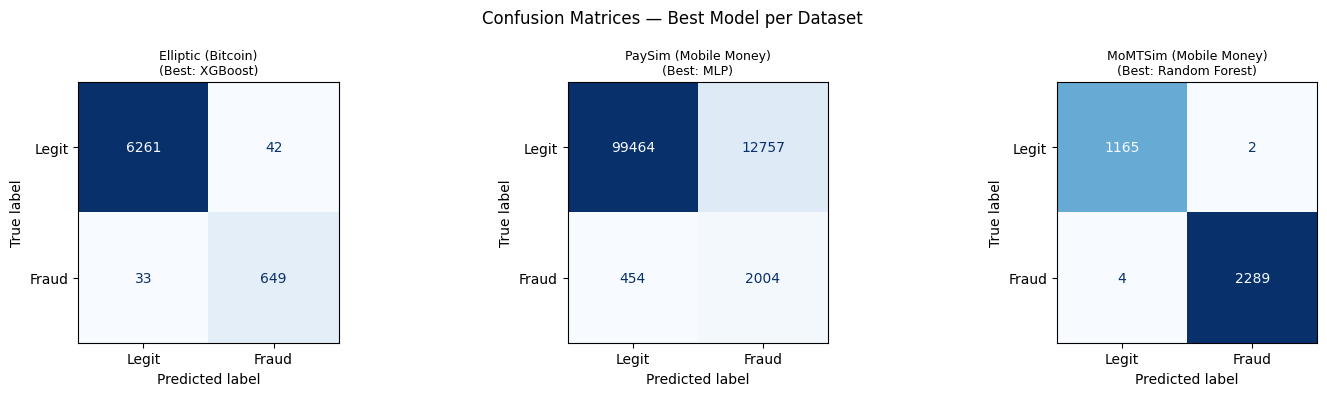

✅ Saved → /content/drive/MyDrive/FraudDetection_Research/datasets/../results/phase1/phase1_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5 * len(DATASETS), 4))

for ax, (ds_name, ds) in zip(axes, DATASETS.items()):
    X_tr, X_te, y_tr, y_te = graph_to_tabular(ds_name, ds)

    # Refit best model (by AUPRC) for this dataset
    best_model_name = (df_res[df_res['dataset'] == ds_name]
                       .sort_values('AUPRC', ascending=False)
                       .iloc[0]['model'])
    best_model = models[best_model_name]

    try:
        k = min(5, int(y_tr.sum()) - 1)
        X_tr_sm, y_tr_sm = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr, y_tr)
    except:
        X_tr_sm, y_tr_sm = X_tr, y_tr

    best_model.fit(X_tr_sm, y_tr_sm)
    y_pred = best_model.predict(X_te)

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Legit', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{ds["name"]}\n(Best: {best_model_name})', fontsize=9)

plt.suptitle('Confusion Matrices — Best Model per Dataset', fontsize=12)
plt.tight_layout()
cm_path = os.path.join(RESULTS_DIR, 'phase1_confusion_matrices.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {cm_path}')


elliptic:
  Train: 32,594 samples | fraud: 3,181 (9.76%)
  Test : 6,985 samples | fraud: 682 (9.76%)

paysim:
  Train: 535,166 samples | fraud: 11,467 (2.14%)
  Test : 114,679 samples | fraud: 2,458 (2.14%)

momtsim:
  Train: 16,143 samples | fraud: 10,700 (66.28%)
  Test : 3,460 samples | fraud: 2,293 (66.27%)


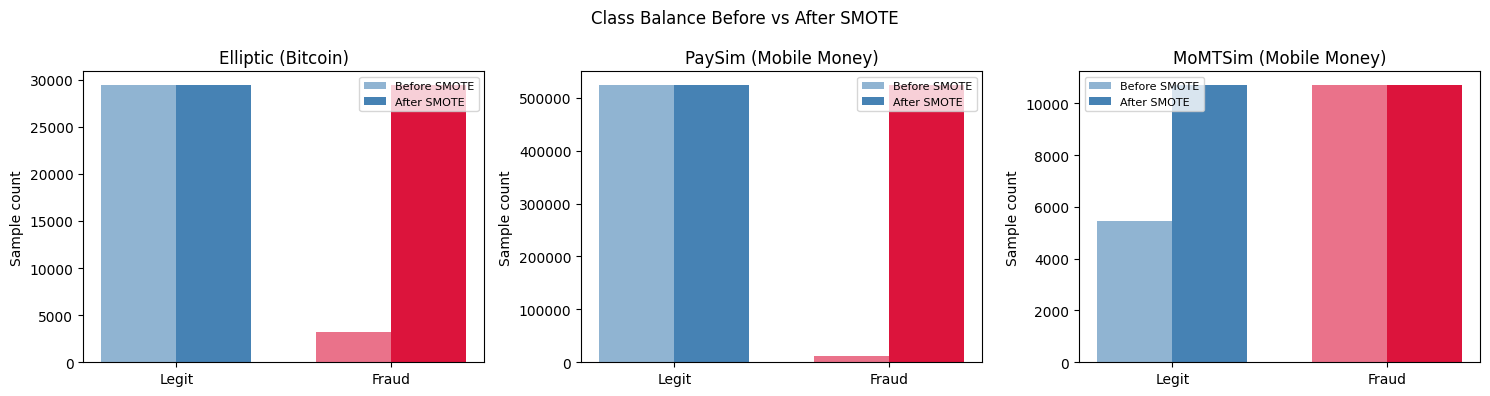

✅ Saved → /content/drive/MyDrive/FraudDetection_Research/datasets/../results/phase1/phase1_smote_effect.png


In [ ]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5 * len(DATASETS), 4))

for ax, (ds_name, ds) in zip(axes, DATASETS.items()):
    X_tr, X_te, y_tr, y_te = graph_to_tabular(ds_name, ds)
    before_fraud = y_tr.sum()
    before_legit = len(y_tr) - before_fraud

    try:
        k = min(5, int(y_tr.sum()) - 1)
        _, y_sm = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr, y_tr)
        after_fraud = y_sm.sum()
        after_legit = len(y_sm) - after_fraud
    except:
        after_fraud, after_legit = before_fraud, before_legit

    x     = np.arange(2)
    width = 0.35
    ax.bar(x - width/2, [before_legit, before_fraud],
           width, label='Before SMOTE', color=['steelblue', 'crimson'], alpha=0.6)
    ax.bar(x + width/2, [after_legit,  after_fraud],
           width, label='After SMOTE',  color=['steelblue', 'crimson'], alpha=1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(['Legit', 'Fraud'])
    ax.set_title(f'{ds["name"]}')
    ax.legend(fontsize=8)
    ax.set_ylabel('Sample count')

plt.suptitle('Class Balance Before vs After SMOTE', fontsize=12)
plt.tight_layout()
smote_path = os.path.join(RESULTS_DIR, 'phase1_smote_effect.png')
plt.savefig(smote_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {smote_path}')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch_geometric -q
!pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html -q

import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from torch_geometric.utils import add_self_loops
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
warnings.filterwarnings('ignore')

DRIVE_BASE  = '/content/drive/MyDrive/FraudDetection_Research/datasets'
RESULTS_DIR = os.path.join(DRIVE_BASE, '../results/phase2'); os.makedirs(RESULTS_DIR, exist_ok=True)

bundle   = torch.load(os.path.join(DRIVE_BASE,'all_datasets.pt'), weights_only=False)
DATASETS = bundle['datasets']
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ {len(DATASETS)} datasets | device: {device}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 3 datasets | device: cuda


In [ ]:
# ── GCN ──────────────────────────────────────────────
class GCN(nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden//2)
        self.conv3 = GCNConv(hidden//2, out_dim)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv3(x, edge_index)


# ── GAT ──────────────────────────────────────────────
class GAT(nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=2, heads=4, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden*heads, hidden, heads=heads, dropout=dropout)
        self.conv3 = GATConv(hidden*heads, out_dim, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv3(x, edge_index)


# ── GraphSAGE ─────────────────────────────────────────
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden)
        self.conv2 = SAGEConv(hidden, hidden//2)
        self.conv3 = SAGEConv(hidden//2, out_dim)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv3(x, edge_index)


print('✅ GCN, GAT, GraphSAGE defined.')

✅ GCN, GAT, GraphSAGE defined.


In [ ]:
def get_loss_weight(y_train_tensor):
    """Compute class weight for imbalanced fraud data."""
    n_neg = (y_train_tensor == 0).sum().float()
    n_pos = (y_train_tensor == 1).sum().float()
    return torch.tensor([1.0, n_neg / (n_pos + 1e-8)]).to(device)


def train_epoch(model, data, optimizer, criterion, train_mask):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate_gnn(model, data, mask):
    model.eval()
    out    = model(data.x, data.edge_index)
    proba  = F.softmax(out[mask], dim=1)[:,1].cpu().numpy()
    pred   = out[mask].argmax(dim=1).cpu().numpy()
    labels = data.y[mask].cpu().numpy()
    # Skip if only one class present
    if len(np.unique(labels)) < 2: return None
    return {
        'AUC-ROC'  : round(roc_auc_score(labels, proba), 4),
        'AUPRC'    : round(average_precision_score(labels, proba), 4),
        'F1'       : round(f1_score(labels, pred, zero_division=0), 4),
        'Precision': round(precision_score(labels, pred, zero_division=0), 4),
        'Recall'   : round(recall_score(labels, pred, zero_division=0), 4),
    }


def run_gnn(model_cls, model_kwargs, data, ds_name, m_name,
             epochs=200, lr=0.01, patience=20):
    """
    Full training loop with early stopping.
    Returns best test metrics.
    """
    # Only train on labelled nodes
    tr_mask  = data.train_mask & (data.y != -1)
    va_mask  = data.val_mask   & (data.y != -1)
    te_mask  = data.test_mask  & (data.y != -1)

    model    = model_cls(**model_kwargs).to(device)
    data_dev = data.to(device)
    w        = get_loss_weight(data_dev.y[tr_mask])
    criterion= nn.CrossEntropyLoss(weight=w)
    optimizer= torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    best_auprc, best_epoch, patience_cnt = 0, 0, 0
    best_state, train_losses, val_auprcs = None, [], []

    for epoch in range(1, epochs+1):
        loss = train_epoch(model, data_dev, optimizer, criterion, tr_mask)
        train_losses.append(loss)
        val_res = evaluate_gnn(model, data_dev, va_mask)
        if val_res is None: continue
        val_auprcs.append(val_res['AUPRC'])

        if val_res['AUPRC'] > best_auprc:
            best_auprc = val_res['AUPRC']
            best_epoch = epoch
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= patience:
            print(f'    Early stop @ epoch {epoch} (best={best_epoch})')
            break

    model.load_state_dict(best_state)
    test_res = evaluate_gnn(model, data_dev, te_mask)
    test_res.update({'model': m_name, 'dataset': ds_name,
                     'best_epoch': best_epoch, 'best_val_auprc': round(best_auprc,4)})

    # Save training curve
    model_path = os.path.join(RESULTS_DIR, f'{ds_name}_{m_name.replace(" ","_")}.pt')
    torch.save(model.state_dict(), model_path)

    return test_res, train_losses, val_auprcs, model


print('✅ Training utilities defined.')

✅ Training utilities defined.


In [ ]:
GNN_CONFIGS = {
    'GCN'       : (GCN,       {}),
    'GAT'       : (GAT,       {'heads': 4}),
    'GraphSAGE' : (GraphSAGE, {}),
}

all_gnn_results = []
training_curves = {}  # for plotting

for ds_name, ds in DATASETS.items():
    g = ds['graph']
    in_dim = g.num_node_features
    print(f'\n{"="*60}')
    print(f' Dataset: {ds["name"]}  |  in_dim={in_dim}')
    print(f'{"="*60}')

    for m_name, (cls, extra) in GNN_CONFIGS.items():
        kwargs = {'in_dim': in_dim, **extra}
        print(f'\n  ▶ {m_name}...')
        res, t_loss, v_auprc, model = run_gnn(
            cls, kwargs, g, ds_name, m_name,
            epochs=100, lr=0.005, patience=25
        )
        all_gnn_results.append(res)
        training_curves[f'{ds_name}_{m_name}'] = (t_loss, v_auprc)
        print(f'    AUC={res["AUC-ROC"]:.4f}  AUPRC={res["AUPRC"]:.4f}  '
              f'F1={res["F1"]:.4f}  best_epoch={res["best_epoch"]}')

print('\n✅ All GNN experiments complete.')


 Dataset: Elliptic (Bitcoin)  |  in_dim=165

  ▶ GCN...
    AUC=0.9616  AUPRC=0.8132  F1=0.6375  best_epoch=96

  ▶ GAT...
    AUC=0.9595  AUPRC=0.7542  F1=0.4746  best_epoch=99

  ▶ GraphSAGE...
    AUC=0.9854  AUPRC=0.9406  F1=0.8329  best_epoch=90

 Dataset: PaySim (Mobile Money)  |  in_dim=12

  ▶ GCN...
    Early stop @ epoch 62 (best=37)
    AUC=1.0000  AUPRC=1.0000  F1=0.9996  best_epoch=37

  ▶ GAT...
    Early stop @ epoch 27 (best=2)
    AUC=1.0000  AUPRC=1.0000  F1=1.0000  best_epoch=2

  ▶ GraphSAGE...
    Early stop @ epoch 38 (best=13)
    AUC=0.9993  AUPRC=0.9988  F1=0.9928  best_epoch=13

 Dataset: MoMTSim (Mobile Money)  |  in_dim=12

  ▶ GCN...
    AUC=0.8660  AUPRC=0.9176  F1=0.7691  best_epoch=100

  ▶ GAT...
    AUC=0.8010  AUPRC=0.8819  F1=0.8553  best_epoch=100

  ▶ GraphSAGE...
    AUC=0.9990  AUPRC=0.9995  F1=0.9848  best_epoch=87

✅ All GNN experiments complete.



=== Phase 2 GNN Results ===
 dataset     model  AUC-ROC  AUPRC     F1  Precision  Recall
elliptic       GCN   0.9616 0.8132 0.6375     0.4975  0.8871
elliptic       GAT   0.9595 0.7542 0.4746     0.3147  0.9648
elliptic GraphSAGE   0.9854 0.9406 0.8329     0.7654  0.9135
  paysim       GCN   1.0000 1.0000 0.9996     1.0000  0.9992
  paysim       GAT   1.0000 1.0000 1.0000     1.0000  1.0000
  paysim GraphSAGE   0.9993 0.9988 0.9928     1.0000  0.9858
 momtsim       GCN   0.8660 0.9176 0.7691     0.8981  0.6725
 momtsim       GAT   0.8010 0.8819 0.8553     0.7685  0.9642
 momtsim GraphSAGE   0.9990 0.9995 0.9848     0.9920  0.9778

✅ Results saved → /content/drive/MyDrive/FraudDetection_Research/datasets/../results/phase2/phase2_gnn_results.csv


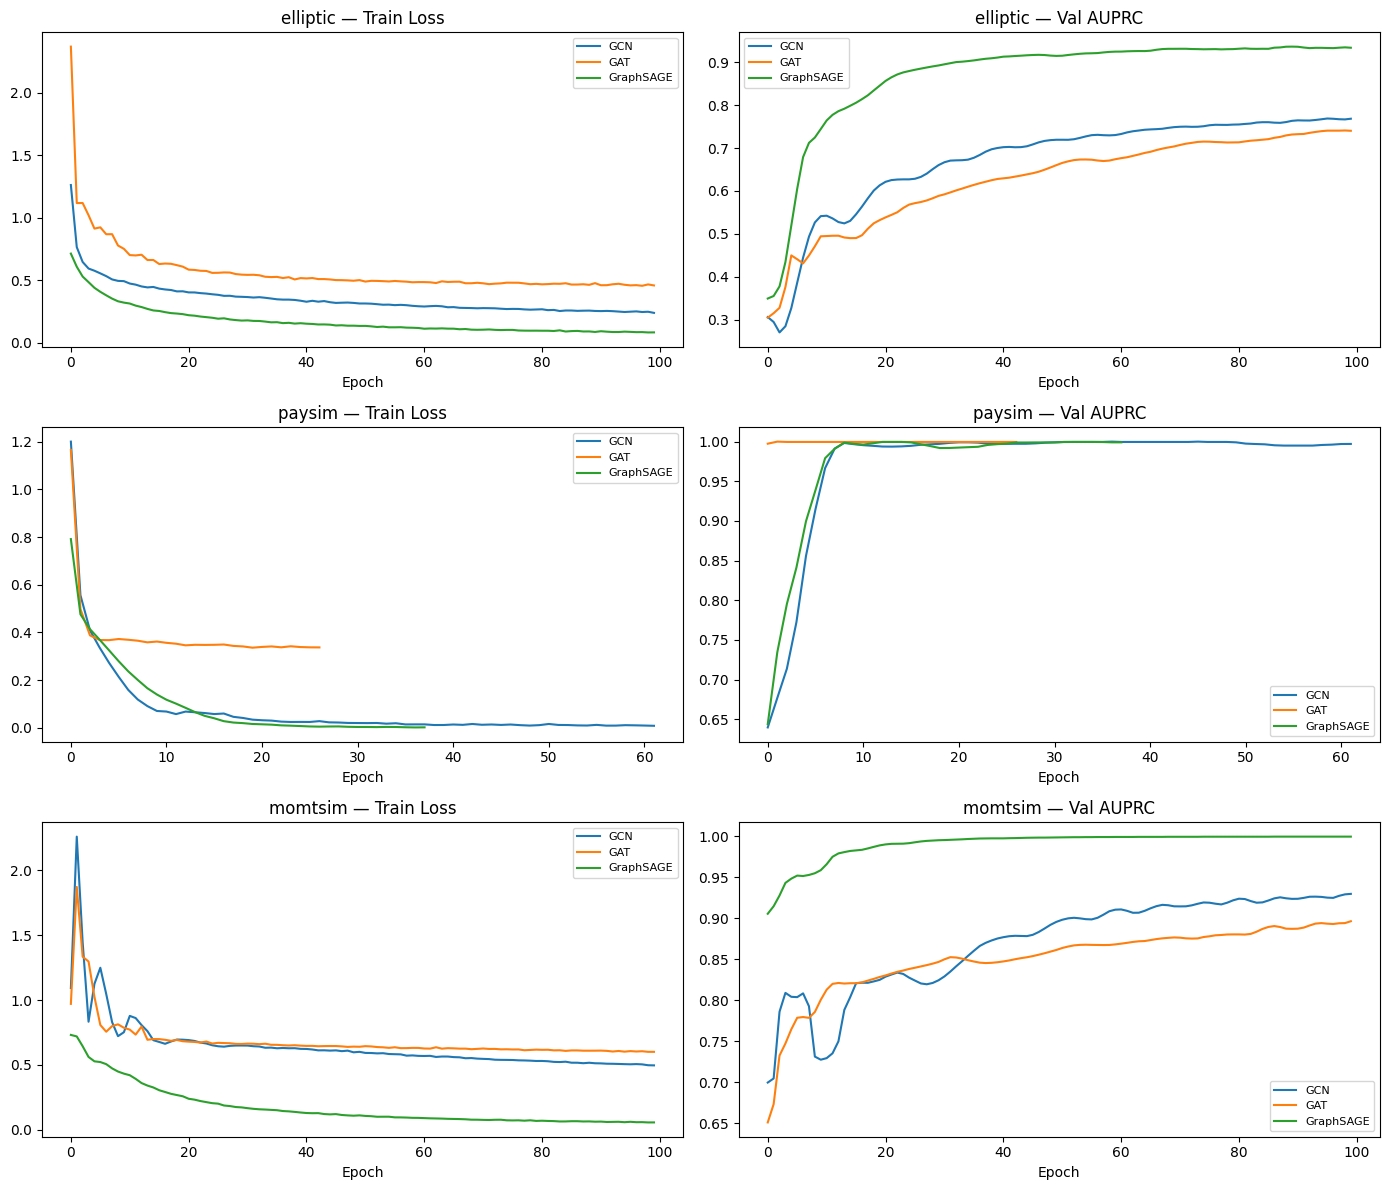

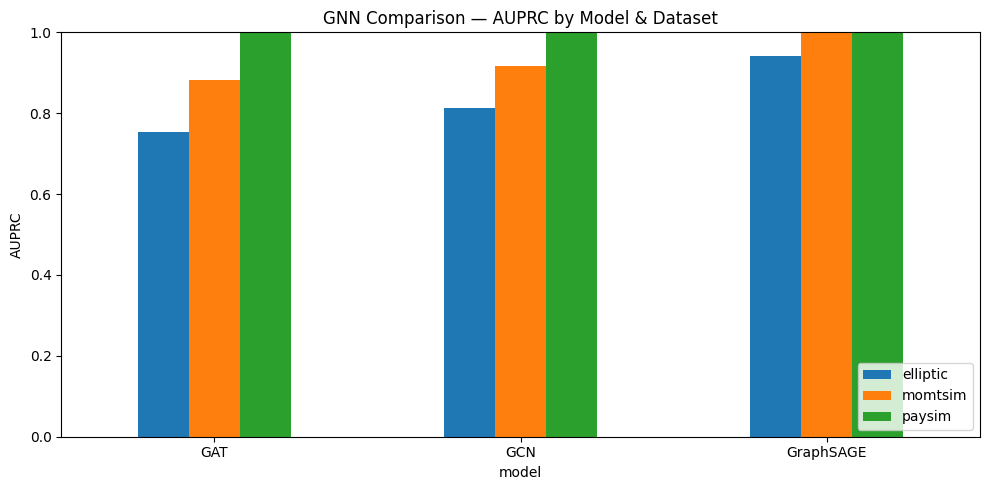

Best GNN per dataset (AUPRC):
 dataset     model  AUC-ROC  AUPRC     F1
elliptic GraphSAGE   0.9854 0.9406 0.8329
 momtsim GraphSAGE   0.9990 0.9995 0.9848
  paysim       GCN   1.0000 1.0000 0.9996


In [ ]:
df_gnn = pd.DataFrame(all_gnn_results)
print('\n=== Phase 2 GNN Results ===')
print(df_gnn[['dataset','model','AUC-ROC','AUPRC','F1','Precision','Recall']].to_string(index=False))

csv_path = os.path.join(RESULTS_DIR,'phase2_gnn_results.csv')
df_gnn.to_csv(csv_path, index=False)
print(f'\n✅ Results saved → {csv_path}')

# ── Training curves ──
n_ds = len(DATASETS)
fig, axes = plt.subplots(n_ds, 2, figsize=(14, 4*n_ds))
if n_ds == 1: axes = [axes]
for row, ds_name in enumerate(DATASETS):
    for col, metric_label in enumerate(['Train Loss', 'Val AUPRC']):
        ax = axes[row][col]
        for m_name in GNN_CONFIGS:
            key = f'{ds_name}_{m_name}'
            if key not in training_curves: continue
            vals = training_curves[key][col]
            ax.plot(vals, label=m_name)
        ax.set_title(f'{ds_name} — {metric_label}')
        ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,'phase2_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Bar chart: AUPRC by model & dataset ──
pivot = df_gnn.pivot(index='model', columns='dataset', values='AUPRC')
pivot.plot(kind='bar', figsize=(10,5), rot=0)
plt.title('GNN Comparison — AUPRC by Model & Dataset')
plt.ylabel('AUPRC'); plt.ylim(0,1); plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,'phase2_auprc_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Best GNN per dataset (AUPRC):')
print(df_gnn.loc[df_gnn.groupby('dataset')['AUPRC'].idxmax()][['dataset','model','AUC-ROC','AUPRC','F1']].to_string(index=False))